# Template Training Causal LM (Instruction Dataset)

Gunakan notebook ini sebagai alur latihan. Setiap bagian hanya berisi instruksi dan Anda mengisi kode di cell kosong di bawahnya.

Tujuan akhir: pipeline lengkap dari load data CSV, preprocessing, training, evaluasi (loss + perplexity), visualisasi, dan inference.

## 1. Import Library

Tulis semua import yang dibutuhkan. Minimal:
- `pandas`, `numpy`, `matplotlib`, `seaborn`
- `torch`, `torch.utils.data`
- `transformers` (misal `AutoTokenizer`, `AutoModelForCausalLM`, `DataCollatorForLanguageModeling`)
- `datasets` (misal `load_dataset`)

Tips: cek versi dengan `__version__` agar gampang debug.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils import data
from transformers import AutoTokenizer, AutoModelForCausalLM, DataCollatorForLanguageModeling
from datasets import load_dataset

print(pd.__version__)

2.3.3


## 2. Load Dataset (CSV) dan Inspect Kolom

Langkah yang perlu ditulis (gunakan pandas + datasets):
- Load CSV dengan `pandas.read_csv()` dan tampilkan `head()`.
- Tampilkan info kolom: `df.columns`, `df.info()`, `df.describe(include='all')`.
- Cek missing value: `df.isna().sum()`.
- Pastikan kolom `instruction`, `input`, `output` ada (atau kolom `text` jika sudah digabung).

Print yang disarankan:
- Jumlah baris dan kolom.
- Contoh 3 baris acak (`df.sample(3, random_state=42)`).

Jika ingin pakai `datasets`, gunakan `load_dataset('csv', data_files=...)` setelah CSV bersih.

In [2]:
df = pd.read_csv('./data/alpaca.csv')

display(df.head(3))

,instruction,input,output,text
0,Give three tips for staying healthy.,NaN,1.Eat a balanced diet and make sure to include...,Below is an instruction that describes a task....
1,What are the three primary colors?,NaN,"The three primary colors are red, blue, and ye...",Below is an instruction that describes a task....
2,Describe the structure of an atom.,NaN,"An atom is made up of a nucleus, which contain...",Below is an instruction that describes a task....


In [3]:
print(df.columns)

Index(['instruction', 'input', 'output', 'text'], dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52002 entries, 0 to 52001
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   instruction  52002 non-null  object
 1   input        20658 non-null  object
 2   output       51971 non-null  object
 3   text         52002 non-null  object
dtypes: object(4)
memory usage: 1.6+ MB


In [5]:
df.describe()

,instruction,input,output,text
count,52002,20658,51971,52002
unique,52002,19184,50840,52002
top,Analyze the given legal document and explain t...,No input,Negative,"Below is an instruction that describes a task,..."
freq,1,161,44,1


In [6]:
df.shape

(52002, 4)

In [7]:
df.isna().sum()

instruction        0
input          31344
output            31
text               0
dtype: int64

## 3. Preprocess: Gabungkan Instruction + Input + Output

Buat fungsi format teks agar konsisten. Contoh struktur:
```
Below is an instruction ...
### Instruction:
{instruction}

### Input:
{input}

### Response:
{output}
```

Instruksi detail:
- Buat fungsi `format_example(row)`.
- Jika `input` kosong/NaN, hilangkan blok Input.
- Simpan ke kolom baru `text`.
- Print contoh hasil format untuk 2-3 baris.

Cek distribusi panjang teks sebelum tokenisasi:
- Buat kolom `text_len` = `df['text'].str.len()`.
- Print statistik: `min`, `max`, `mean`, `median`.
- Visualisasi distribusi dengan `hist`/`seaborn.histplot`.

=== Contoh 1 ===
Below is an instruction that describes a task.
### Instruction:
Give three tips for staying healthy.

### Response:
1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. 
2. Exercise regularly to keep your body active and strong. 
3. Get enough sleep and maintain a consistent sleep schedule.

=== Contoh 2 ===
Below is an instruction that describes a task.
### Instruction:
What are the three primary colors?

### Response:
The three primary colors are red, blue, and yellow.

=== Statistik Panjang Teks ===
count    52002.000000
mean       438.078689
std        277.433707
min         94.000000
25%        226.000000
50%        361.000000
75%        585.000000
max       4384.000000
Name: text_len, dtype: float64


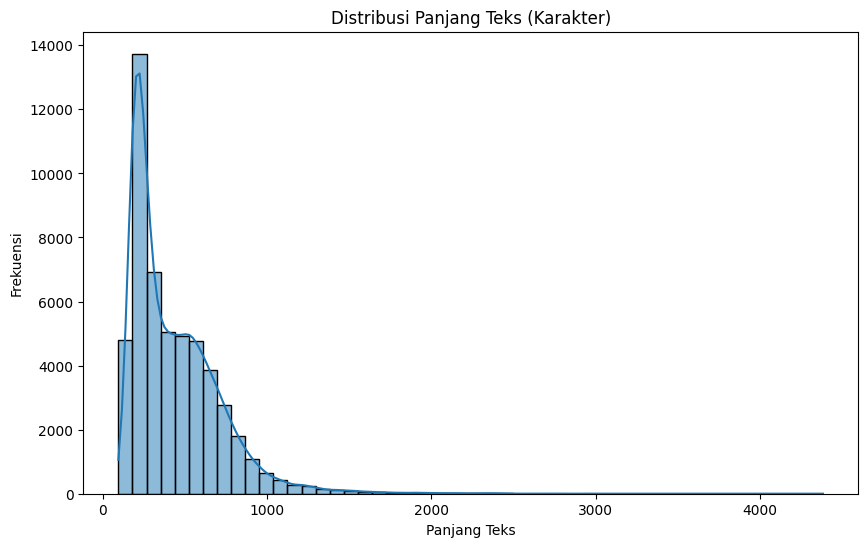

In [8]:
def format_example(row):
    instruction = str(row['instruction']).strip() if pd.notna(row['instruction']) else ""
    user_input = str(row['input']).strip() if pd.notna(row['input']) else ""
    output = str(row['output']).strip() if pd.notna(row['output']) else ""
    
    parts = ["Below is an instruction that describes a task."]
    parts.append("### Instruction:")
    parts.append(instruction)
    
    if user_input and user_input.lower() != "no input" and user_input != "nan":
        parts.append("\n### Input:")
        parts.append(user_input)
        
    parts.append("\n### Response:")
    parts.append(output)
    
    return "\n".join(parts)

# Buat kolom baru 'text'
df['text'] = df.apply(format_example, axis=1)

# Tampilkan beberapa contoh
print("=== Contoh 1 ===")
print(df['text'].iloc[0])
print("\n=== Contoh 2 ===")
print(df['text'].iloc[1])

# Cek distribusi panjang teks sebelum tokenisasi
df['text_len'] = df['text'].str.len()
print("\n=== Statistik Panjang Teks ===")
print(df['text_len'].describe())

# Visualisasi distribusi panjang teks
plt.figure(figsize=(10, 6))
sns.histplot(df['text_len'], bins=50, kde=True)
plt.title("Distribusi Panjang Teks (Karakter)")
plt.xlabel("Panjang Teks")
plt.ylabel("Frekuensi")
plt.show()

## 4. Tokenisasi dan Split Dataset

Langkah yang perlu ada:
- Load tokenizer: `AutoTokenizer.from_pretrained()`.
- Tentukan `max_length` (misal 128/256) berdasar distribusi panjang teks.
- Tokenisasi kolom `text` (gunakan `truncation=True`, `padding='max_length'`).
- Buat fungsi `tokenize_function(examples)` lalu `dataset.map(...)`.

Split dataset:
- Jika belum ada, buat split `train/valid/test` dengan `train_test_split()`.
- Print jumlah data per split.

Cek distribusi panjang token:
- Ambil `len(input_ids)` untuk beberapa contoh.
- Plot histogram panjang token.

Jumlah Data Train: 41576
Jumlah Data Validation: 5197
Jumlah Data Test: 5198


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/41576 [00:00<?, ? examples/s]

Map:   0%|          | 0/5197 [00:00<?, ? examples/s]

Map:   0%|          | 0/5198 [00:00<?, ? examples/s]


Min token length (tanpa pad): 28
Max token length (tanpa pad): 579
Mean token length (tanpa pad): 96.94


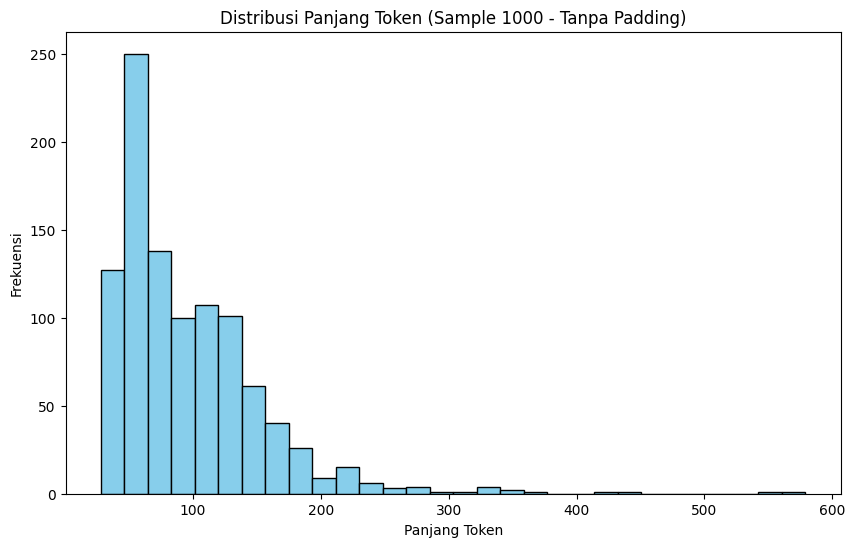

In [9]:
from sklearn.model_selection import train_test_split
from datasets import Dataset

# Split dataset menjadi Train (80%), Validation (10%), Test (10%)
df = df.dropna(subset=['output'])
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Jumlah Data Train: {len(train_df)}")
print(f"Jumlah Data Validation: {len(val_df)}")
print(f"Jumlah Data Test: {len(test_df)}")

# Load tokenizer
model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# Tentukan max_length
max_length = 256

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        max_length=max_length,
        padding='max_length'
    )

# Konversi ke Hugging Face Dataset dan lakukan pemetaan tokenisasi
train_dataset = Dataset.from_pandas(train_df).map(tokenize_function, batched=True)
val_dataset = Dataset.from_pandas(val_df).map(tokenize_function, batched=True)
test_dataset = Dataset.from_pandas(test_df).map(tokenize_function, batched=True)

# Ambil contoh panjang token untuk visualisasi histogram
original_lengths = [len(tokenizer.encode(t)) for t in train_df['text'].sample(1000, random_state=42)]

print(f"\nMin token length (tanpa pad): {min(original_lengths)}")
print(f"Max token length (tanpa pad): {max(original_lengths)}")
print(f"Mean token length (tanpa pad): {np.mean(original_lengths):.2f}")

plt.figure(figsize=(10, 6))
plt.hist(original_lengths, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribusi Panjang Token (Sample 1000 - Tanpa Padding)")
plt.xlabel("Panjang Token")
plt.ylabel("Frekuensi")
plt.show()

## 5. Load Model & Tokenizer

Instruksi detail:
- Pilih model Causal LM kecil (misal `gpt2` atau `distilgpt2`).
- Load `AutoModelForCausalLM` dan `AutoTokenizer`.
- Set `tokenizer.pad_token = tokenizer.eos_token` jika perlu.
- Print konfigurasi singkat model: `model.config`.

Opsional: set `torch.device` dan pindahkan model ke device.

In [10]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

model_name = "distilgpt2"
model = AutoModelForCausalLM.from_pretrained(model_name)
model.to(device)

print("\n=== Konfigurasi Model ===")
print(model.config)

Menggunakan device: cuda


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


=== Konfigurasi Model ===
GPT2Config {
  "_num_labels": 1,
  "activation_function": "gelu_new",
  "add_cross_attention": false,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "dtype": "float32",
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "id2label": {
    "0": "LABEL_0"
  },
  "initializer_range": 0.02,
  "label2id": {
    "LABEL_0": 0
  },
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 6,
  "n_positions": 1024,
  "pad_token_id": null,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "tie_word_embe

## 6. DataLoader & Collator

Instruksi detail:
- Gunakan `DataCollatorForLanguageModeling` (set `mlm=False`).
- Buat `DataLoader` untuk train dan valid.
- Pastikan batch berisi `input_ids`, `attention_mask`, dan `labels`.

Print debug:
- Ambil 1 batch dan print `batch.keys()` serta shape tensor.

In [11]:
from torch.utils.data import DataLoader

# Format dataset untuk PyTorch
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask'])

# Buat Data Collator
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# Buat DataLoader
batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=data_collator)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=data_collator)

# Ambil 1 batch untuk debugging
debug_batch = next(iter(train_loader))
print("Keys dalam batch:", debug_batch.keys())
print("Shape input_ids:", debug_batch['input_ids'].shape)
print("Shape attention_mask:", debug_batch['attention_mask'].shape)
print("Shape labels:", debug_batch['labels'].shape)

Keys dalam batch: KeysView({'input_ids': tensor([[21106,   318,   281,  ..., 50256, 50256, 50256],
        [21106,   318,   281,  ..., 50256, 50256, 50256],
        [21106,   318,   281,  ..., 50256, 50256, 50256],
        [21106,   318,   281,  ..., 50256, 50256, 50256]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]]), 'labels': tensor([[21106,   318,   281,  ...,  -100,  -100,  -100],
        [21106,   318,   281,  ...,  -100,  -100,  -100],
        [21106,   318,   281,  ...,  -100,  -100,  -100],
        [21106,   318,   281,  ...,  -100,  -100,  -100]])})
Shape input_ids: torch.Size([4, 256])
Shape attention_mask: torch.Size([4, 256])
Shape labels: torch.Size([4, 256])


## 7. Training Loop

Buat training loop manual:
- Inisialisasi optimizer (`AdamW`) dan learning rate.
- Loop per epoch dan per batch.
- `forward` -> `loss` -> `backward` -> `optimizer.step()`.
- Simpan `train_loss` per step/epoch ke list.

Print yang disarankan:
- Loss per beberapa step.
- Rata-rata loss per epoch.

In [12]:
from torch.optim import AdamW
from tqdm.auto import tqdm

epochs = 1
lr = 5e-5

optimizer = AdamW(model.parameters(), lr=lr)
model.train()

train_losses = []
limit_batches = 50  # Batasi 50 batch agar demo berjalan cepat di CPU/Lokal

print(f"Memulai pelatihan pada {device}...")
for epoch in range(epochs):
    epoch_loss = 0
    steps = 0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for batch_idx, batch in enumerate(progress_bar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        
        loss_val = loss.item()
        train_losses.append(loss_val)
        epoch_loss += loss_val
        steps += 1
        
        progress_bar.set_postfix({"loss": f"{loss_val:.4f}"})
        
        if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss_val:.4f}")
            
        if limit_batches is not None and steps >= limit_batches:
            print(f"\nPelatihan dihentikan lebih awal pada batch ke-{limit_batches} untuk demo cepat.")
            break
            
    avg_epoch_loss = epoch_loss / steps
    print(f"=== Epoch {epoch+1} Selesai | Rata-rata Loss: {avg_epoch_loss:.4f} ===\n")

Memulai pelatihan pada cuda...


Epoch 1/1:   0%|          | 0/10394 [00:00<?, ?it/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch 1 | Batch 0/10394 | Loss: 3.4623
Epoch 1 | Batch 10/10394 | Loss: 2.8044
Epoch 1 | Batch 20/10394 | Loss: 2.2686
Epoch 1 | Batch 30/10394 | Loss: 2.7085
Epoch 1 | Batch 40/10394 | Loss: 2.1887

Pelatihan dihentikan lebih awal pada batch ke-50 untuk demo cepat.
=== Epoch 1 Selesai | Rata-rata Loss: 2.6267 ===



## 8. Evaluasi (Loss & Perplexity)

Instruksi detail:
- Set `model.eval()`.
- Loop valid loader dengan `torch.no_grad()`.
- Hitung rata-rata `valid_loss`.
- Hitung perplexity: $\exp(\text{valid_loss})$.

Print:
- `valid_loss` dan `perplexity`.

In [13]:
import math

model.eval()
val_loss = 0
val_steps = 0

limit_val_batches = 20  # Batasi 20 batch evaluasi agar cepat

print("Memulai evaluasi...")
with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(val_loader, desc="Mengevaluasi")):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        val_loss += loss.item()
        val_steps += 1
        
        if limit_val_batches is not None and val_steps >= limit_val_batches:
            break

avg_val_loss = val_loss / val_steps
perplexity = math.exp(avg_val_loss)

print("\n=== Hasil Evaluasi ===")
print(f"Validation Loss: {avg_val_loss:.4f}")
print(f"Perplexity: {perplexity:.4f}")

Memulai evaluasi...


Mengevaluasi:   0%|          | 0/1300 [00:00<?, ?it/s]


=== Hasil Evaluasi ===
Validation Loss: 2.2768
Perplexity: 9.7454


## 9. Visualisasi Loss Curve

Instruksi detail:
- Plot `train_loss` dan `valid_loss` dengan matplotlib.
- Tambahkan label, judul, dan grid.
- Simpan plot jika perlu (`plt.savefig`).

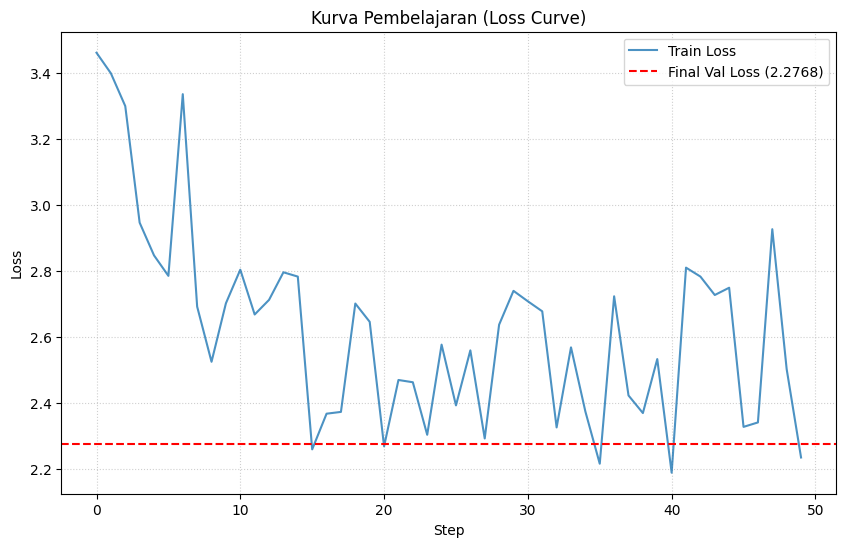

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', color='#1f77b4', alpha=0.8)
plt.axhline(y=avg_val_loss, color='r', linestyle='--', label=f'Final Val Loss ({avg_val_loss:.4f})')
plt.title("Kurva Pembelajaran (Loss Curve)")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig("loss_curve.png", dpi=300)
plt.show()

## 10. Inference Setelah Training

Instruksi detail:
- Siapkan prompt singkat.
- Tokenisasi prompt, pindahkan ke device.
- Gunakan `model.generate()` dengan parameter dasar (`max_new_tokens`, `temperature`, `do_sample`).
- Decode hasil dan print.

Tips: bandingkan hasil sebelum vs sesudah training.

In [15]:
# Siapkan prompt singkat menggunakan format instruksi
prompt_instruction = "Give three tips for staying healthy."
prompt_text = f"Below is an instruction that describes a task.\n### Instruction:\n{prompt_instruction}\n\n### Response:\n"

print("Prompt:")
print(prompt_text)

# Tokenisasi prompt dan pindahkan ke device
inputs = tokenizer(prompt_text, return_tensors="pt").to(device)

# Hasilkan output menggunakan model
model.eval()
with torch.no_grad():
    generated_ids = model.generate(
        input_ids=inputs['input_ids'],
        attention_mask=inputs['attention_mask'],
        max_new_tokens=100,
        temperature=0.7,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )

# Decode hasil dan cetak
generated_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
print("\nHasil Dekode Inference:")
print(generated_text)

Prompt:
Below is an instruction that describes a task.
### Instruction:
Give three tips for staying healthy.

### Response:


Hasil Dekode Inference:
Below is an instruction that describes a task.
### Instruction:
Give three tips for staying healthy.

### Response:
Stay healthy, eat healthy.

### Response:
Stay healthy, eat healthy.

### Response:
Stay healthy, eat healthy.

### Response:
Stay healthy, eat healthy.

### Response:
Stay healthy, eat healthy.

### Response:
Stay healthy, eat healthy.

### Response:
Stay healthy, eat healthy.

### Response:
Stay healthy, eat healthy.

### Response:
Stay healthy, eat
